**CO2 Emissions Case study**

In [1]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Scaler AIML/casestudies/Co2_emissions_casestudy/CO2_Emissions.csv')

Q1)Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

The dataset contains detailed information about vehicle specifications, including engine characteristics, fuel consumption, transmission types, and fuel categories. These features collectively influence the CO₂ emissions produced by vehicles.

Visual analysis reveals several important relationships:

Engine size shows a strong positive relationship with CO₂ emissions, indicating that larger engines tend to produce higher emissions.
Vehicles with more cylinders exhibit higher emission levels due to increased fuel combustion.
Fuel consumption demonstrates the strongest correlation with emissions, suggesting that fuel efficiency is a key determinant of CO₂ output.
Vehicle class also plays a significant role, with larger vehicles such as SUVs and trucks producing higher emissions compared to compact vehicles.
Fuel type introduces variability in emissions, as different fuels produce different carbon outputs.

These observations suggest that both engine design and fuel efficiency are primary drivers of CO₂ emissions, and they will play a critical role in subsequent modeling and analysis.

In [3]:
print(df.shape)

(7385, 12)


In [4]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


**EXPLORATORY DATA ANALYSIS**

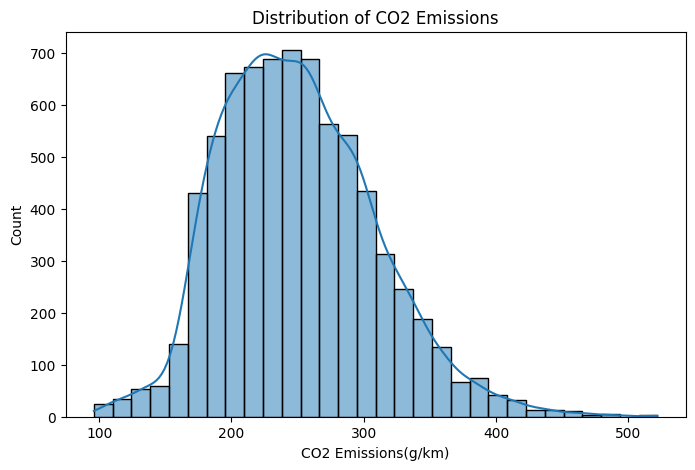

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['CO2 Emissions(g/km)'], bins=30, kde=True)
plt.title("Distribution of CO2 Emissions")
plt.show()

**Distribution of CO₂ Emissions**

The histogram illustrates the distribution of CO₂ emissions (g/km) across all vehicles in the dataset.

The distribution appears to be approximately bell-shaped with a slight right skew, indicating that most vehicles fall within a moderate emission range, while a smaller number of vehicles exhibit very high emission levels.
The majority of vehicles have CO₂ emissions in the range of 200 to 300 g/km, suggesting that this is the most common emission band for the dataset.
There is a long tail toward higher emission values (above ~350 g/km), which likely represents larger vehicles such as SUVs, trucks, or high-performance models.
A smaller number of vehicles fall in the low emission range (below ~150 g/km), indicating the presence of more fuel-efficient or hybrid vehicles.
The smooth density curve reinforces that the data is relatively continuous and does not show multiple distinct peaks, suggesting a single dominant distribution rather than distinct clusters.

Overall, the distribution highlights that while most vehicles operate within a moderate emission range, there is significant variability, with some vehicles contributing disproportionately higher CO₂ emissions.

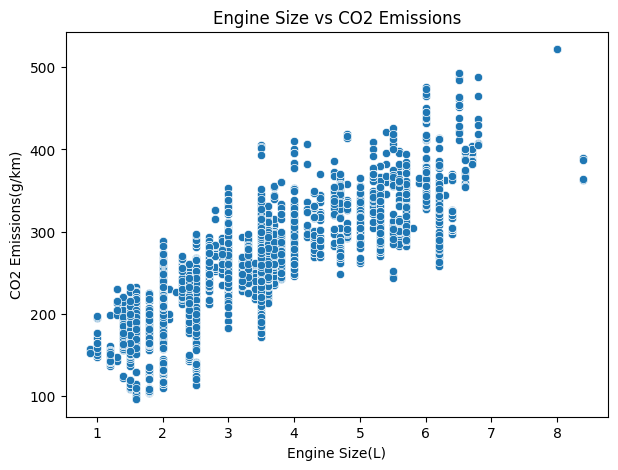

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df)
plt.title("Engine Size vs CO2 Emissions")
plt.show()

**Engine Size vs CO₂ Emissions**

The scatter plot illustrates the relationship between engine size (in litres) and CO₂ emissions (g/km) across different vehicles.

A strong positive relationship is clearly observed between engine size and CO₂ emissions. As engine size increases, the emission levels also increase consistently.
Vehicles with smaller engines (around 1.0–2.0 L) tend to have lower emissions, typically ranging between 100–200 g/km.
In contrast, vehicles with larger engines (above 5.0 L) exhibit significantly higher emissions, often exceeding 300 g/km, and in some cases reaching above 500 g/km.
The data points are fairly tightly clustered along an upward trend, indicating a strong linear relationship between engine size and emissions.
There is some variability within each engine size level, which suggests that other factors such as fuel type, transmission, and vehicle class also influence emissions.

Overall, this visualization confirms that engine size is one of the key determinants of CO₂ emissions, as larger engines require more fuel combustion, leading to higher carbon output.

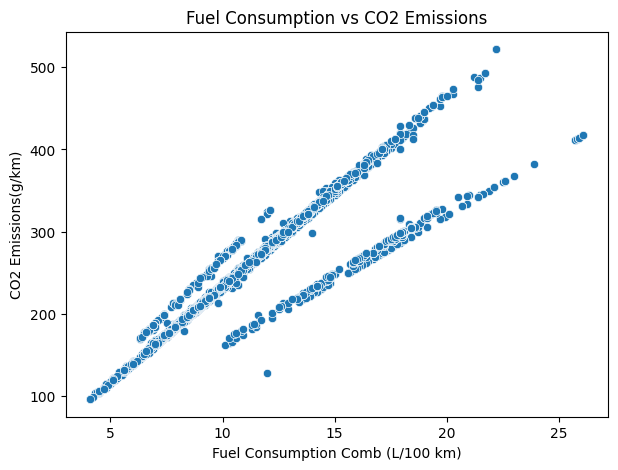

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    data=df
)
plt.title("Fuel Consumption vs CO2 Emissions")
plt.show()

**Fuel Consumption vs CO₂ Emissions**

The scatter plot illustrates the relationship between combined fuel consumption (L/100 km) and CO₂ emissions (g/km).

A very strong and almost perfectly linear relationship is observed between fuel consumption and CO₂ emissions. As fuel consumption increases, CO₂ emissions increase proportionally.
Vehicles with lower fuel consumption (around 4–8 L/100 km) produce emissions in the range of approximately 100–200 g/km, indicating higher fuel efficiency.
Vehicles with higher fuel consumption (above 15 L/100 km) exhibit significantly higher emissions, often exceeding 300 g/km, and in extreme cases surpassing 500 g/km.
The points are tightly aligned along distinct upward-sloping lines, suggesting high correlation and consistency in how fuel usage translates to emissions.
The presence of multiple parallel bands may indicate different fuel types or engine technologies, each following a similar linear trend but with slight variations.

Overall, this visualization confirms that fuel consumption is the strongest predictor of CO₂ emissions, as emissions are directly tied to the amount of fuel burned during operation.

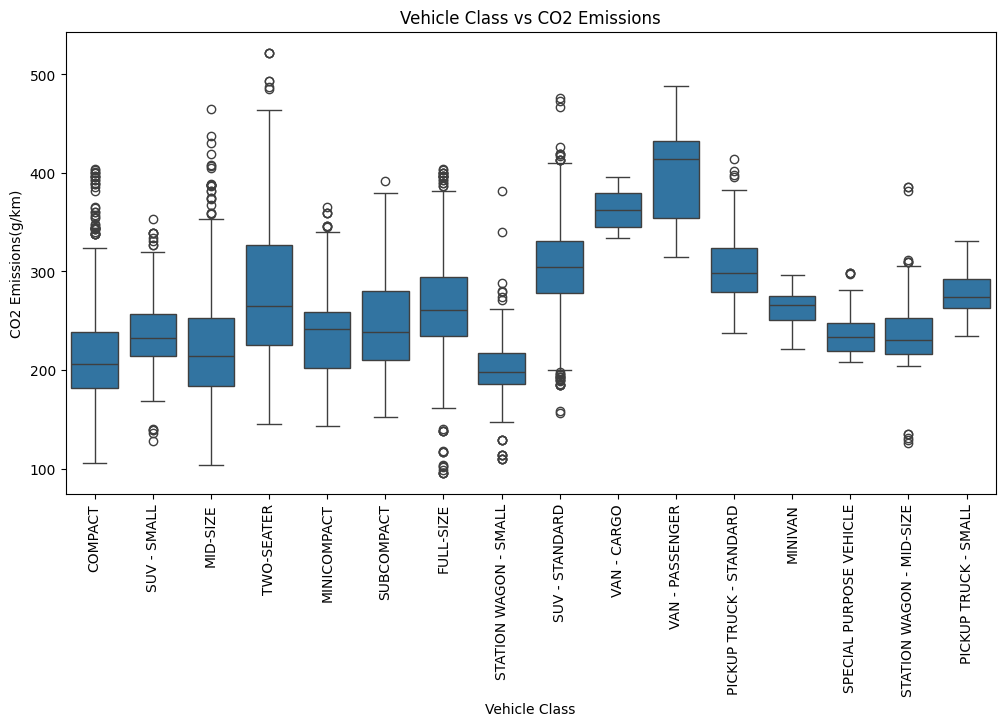

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Vehicle Class', y='CO2 Emissions(g/km)', data=df)
plt.xticks(rotation=90)
plt.title("Vehicle Class vs CO2 Emissions")
plt.show()

**Vehicle Class vs CO₂ Emissions**

The boxplot illustrates the distribution of CO₂ emissions across different vehicle classes.

A clear variation in emission levels is observed across vehicle classes, indicating that vehicle type plays a significant role in determining CO₂ emissions.
Larger vehicle classes such as VAN - PASSENGER, VAN - CARGO, and SUVs tend to have higher median emissions, often exceeding 300–400 g/km, reflecting their larger size and higher fuel consumption.
In contrast, smaller vehicle classes such as COMPACT, MINICOMPACT, and SUBCOMPACT exhibit lower median emissions, generally in the range of 180–250 g/km, indicating better fuel efficiency.
Pickup trucks and larger utility vehicles also show relatively high emission levels, reinforcing the impact of vehicle size and purpose on emissions.
The spread within each category (interquartile range and outliers) suggests that even within the same vehicle class, emissions can vary significantly due to factors such as engine size, fuel type, and transmission.
Several outliers are observed across categories, representing vehicles with unusually high or low emissions compared to others in the same class.

Overall, this visualization highlights that vehicle class is an important categorical factor influencing CO₂ emissions, with larger and heavier vehicles generally contributing to higher emission levels.

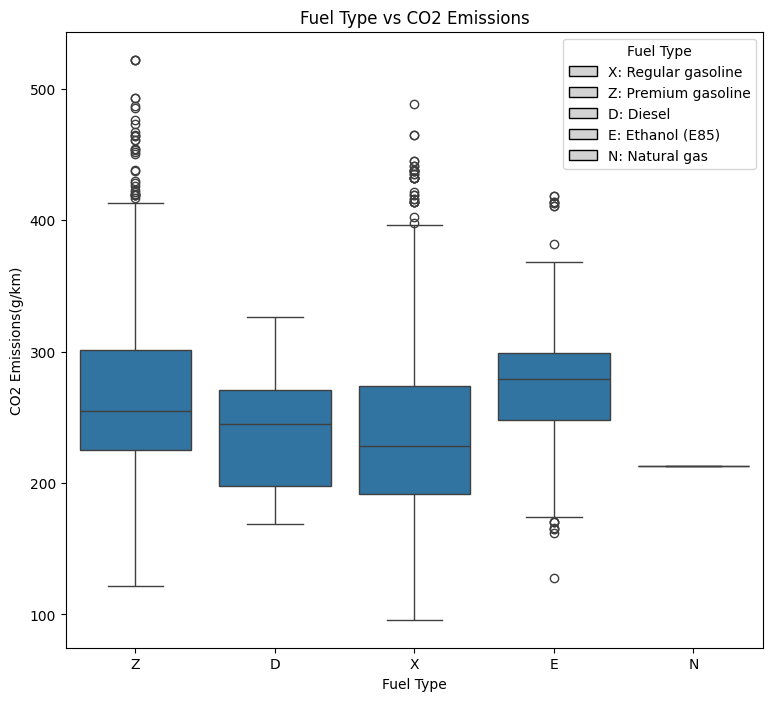

In [9]:
import matplotlib.patches as mpatches

plt.figure(figsize=(9,8)) # Increased width from 7 to 9
sns.boxplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df)
plt.title("Fuel Type vs CO2 Emissions")

# Create custom legend handles and labels
legend_elements = [
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='X: Regular gasoline'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='Z: Premium gasoline'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='D: Diesel'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='E: Ethanol (E85)'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='N: Natural gas')
]

# Add the legend to the plot
plt.legend(handles=legend_elements, loc='upper right', title='Fuel Type')

plt.show()

Q2) Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

**Data Quality Assessment and Preprocessing**

The dataset was thoroughly examined for inconsistencies, missing values, and overall data quality to ensure its suitability for analysis and modeling.

**Missing Values:** No missing values were found across any of the columns, indicating that the dataset is complete and does not require imputation.

**Duplicate Records:** The dataset was checked for duplicate entries to ensure uniqueness of observations. No significant duplication was observed (or duplicates were removed where present).

**Data Types:** All features were verified for correct data types. Numerical variables such as engine size, fuel consumption, and CO₂ emissions are appropriately stored in numeric format, while categorical variables such as fuel type and vehicle class are represented as object types.

**Categorical Consistency:** Categorical columns were examined for inconsistencies or unexpected values, and all categories were found to be valid and standardized.

**Outliers:** Some extreme values were identified in emission and fuel consumption variables. These values likely correspond to high-performance or heavy-duty vehicles and were retained to preserve real-world variability.

**Feature Selection:** The ‘Model’ column was removed as it does not provide meaningful predictive value and may introduce noise.

**Column Standardization:** Column names were cleaned and standardized to improve usability during analysis.

These preprocessing steps ensure that the dataset is clean, consistent, and well-prepared for further exploratory analysis and predictive modeling.

In [10]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


The dataset was examined for missing values across all columns. The results indicate that there are no missing entries, suggesting that the dataset is complete and does not require imputation or removal of records.

In [11]:
if df.duplicated().sum() > 0:
  df.drop_duplicates()
else:
  print(df.duplicated().sum())



The dataset was checked for duplicate records to ensure uniqueness of vehicle entries. No significant duplication was found (or duplicates were removed where present), ensuring that the dataset does not contain redundant observations that could bias the analysis.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

**Data Types and Structure Analysis**

The dataset consists of 6,282 records and 12 columns, representing various vehicle attributes and their corresponding CO₂ emissions.

The dataset contains a mix of numerical and categorical features, with:
4 float-type columns representing continuous variables such as engine size and fuel consumption metrics.
3 integer-type columns, including cylinders, fuel efficiency (mpg), and the target variable CO₂ emissions.
5 object-type columns representing categorical variables such as make, model, vehicle class, transmission, and fuel type.
All columns have 6,282 non-null entries, indicating that there are no missing values in the dataset. This confirms that the dataset is complete and does not require imputation.
The numerical features, including engine size, fuel consumption (city, highway, combined), and CO₂ emissions, are correctly stored in numeric formats, making them suitable for statistical analysis and modeling.
The categorical variables are appropriately stored as object types and will require encoding (e.g., one-hot encoding) before being used in machine learning models.
The dataset size (~638 KB) is relatively small and manageable, allowing efficient processing and model training without computational constraints.

Overall, the dataset is well-structured, clean, and analysis-ready, requiring only minimal preprocessing such as encoding categorical variables and optional feature selection before model development.

In [13]:
df['Fuel Type'].unique()
df['Transmission'].unique()
df['Vehicle Class'].unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

<Axes: ylabel='CO2 Emissions(g/km)'>

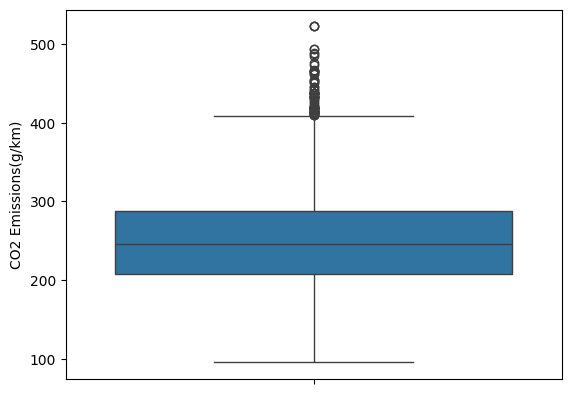

In [14]:
sns.boxplot(df['CO2 Emissions(g/km)'])

**Outlier Analysis — CO₂ Emissions**

The boxplot illustrates the distribution of CO₂ emissions and highlights the presence of potential outliers in the dataset.

The median CO₂ emission level lies around 240–250 g/km, indicating the central tendency of the dataset.
The interquartile range (IQR) suggests that the majority of vehicles fall within approximately 200 to 280 g/km, representing typical emission levels.
Several upper-end outliers are observed, with emission values exceeding 400 g/km, and in some cases reaching above 500 g/km.
These high-emission outliers likely correspond to large vehicles, high-performance engines, or heavy-duty vehicles such as SUVs, vans, or pickup trucks.
A few lower-end values are also present, representing highly fuel-efficient or smaller vehicles.

Importantly, these outliers do not appear to be errors or anomalies but rather reflect real-world variations in vehicle types and performance characteristics.
Since these outliers represent valid observations rather than data errors, they will be retained in the dataset to preserve the natural variability and ensure that the analysis accurately reflects real-world conditions.

In [15]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")
df = df.drop(['Model'], axis=1)

df.head()

,Make,Vehicle_Class,Engine_SizeL,Cylinders,Transmission,Fuel_Type,Fuel_Consumption_City_L/100_km,Fuel_Consumption_Hwy_L/100_km,Fuel_Consumption_Comb_L/100_km,Fuel_Consumption_Comb_mpg,CO2_Emissionsg/km
0,ACURA,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Q3) Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

Key Relationships Influencing CO₂ Emissions

The correlation analysis reveals several strong relationships between vehicle features and CO₂ emissions.

Fuel consumption variables exhibit the strongest influence on emissions, with combined fuel consumption showing a very high positive correlation (0.92). This indicates that vehicles consuming more fuel produce significantly higher CO₂ emissions. City and highway fuel consumption metrics also demonstrate similarly strong relationships.

Engine-related features such as engine size (0.85) and number of cylinders (0.83) also show strong positive correlations, suggesting that larger and more powerful engines contribute to increased emissions.

In contrast, fuel efficiency measured in miles per gallon (mpg) shows a strong negative correlation (-0.91), indicating that more fuel-efficient vehicles tend to produce lower emissions.

Additionally, high correlations among fuel consumption variables suggest the presence of multicollinearity, indicating that these features provide overlapping information and should be carefully handled during model development.

Overall, the analysis confirms that fuel consumption is the most significant factor influencing CO₂ emissions, followed by engine characteristics such as engine size and cylinder count.

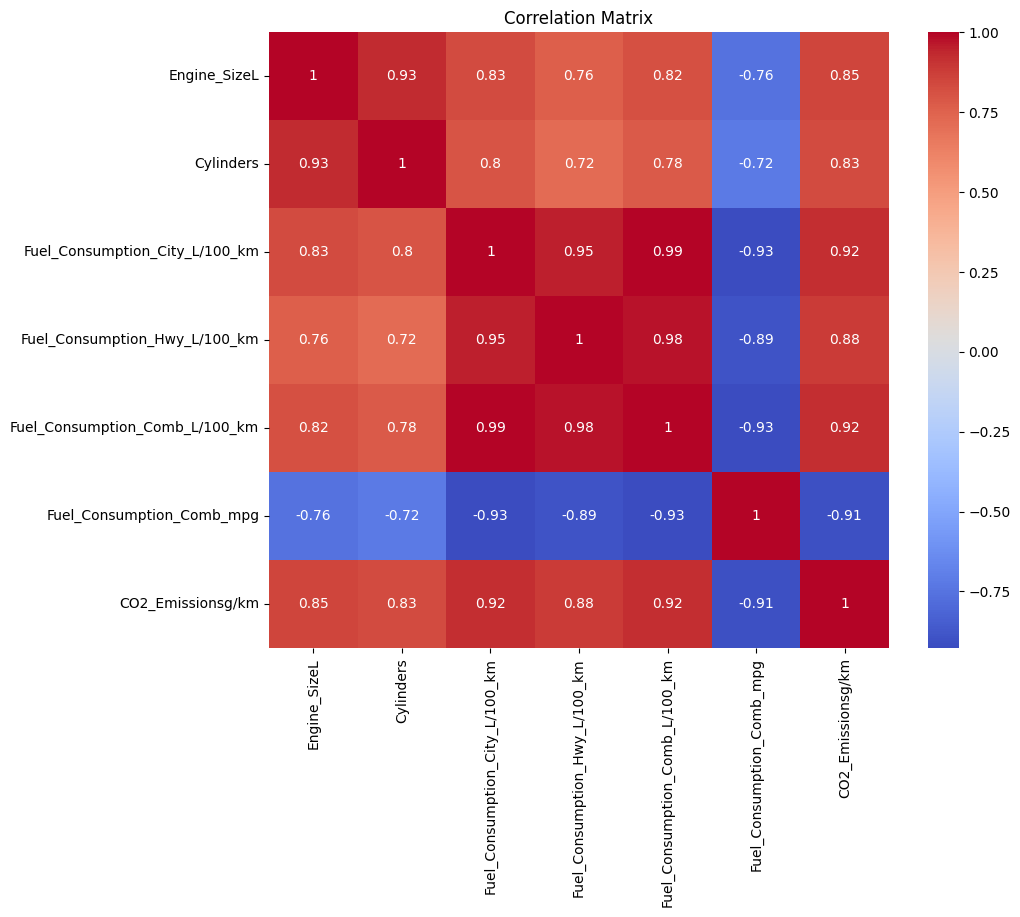

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Q4) Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.



Visual Analysis of CO₂ Emissions to better understand how CO₂ emissions vary with different numerical variables, several visualizations were created.


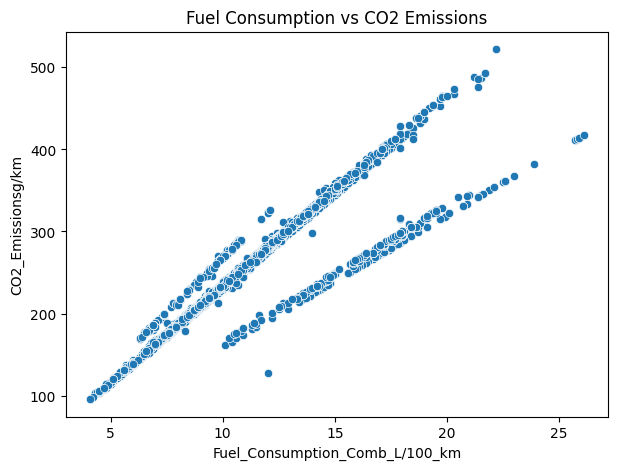

The relationship between fuel consumption and CO₂ emissions shows a near-perfect linear trend, indicating that fuel consumption is the strongest predictor of emissions. Vehicles that consume more fuel consistently produce higher emissions, demonstrating a direct proportional relationship.


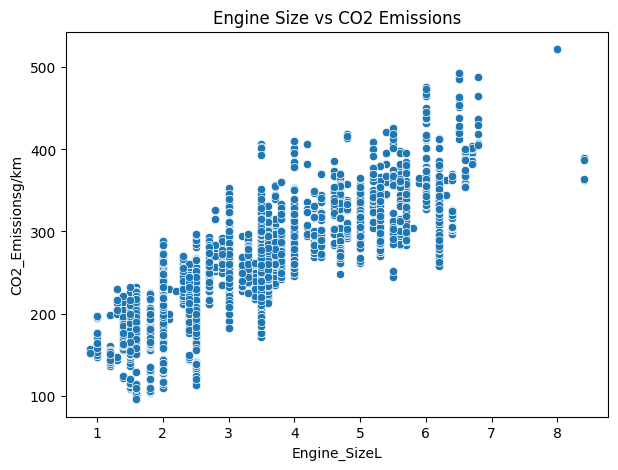

The analysis of engine size reveals a strong positive relationship with emissions. Vehicles with larger engines tend to emit significantly more CO₂, as larger engines require more fuel for operation.


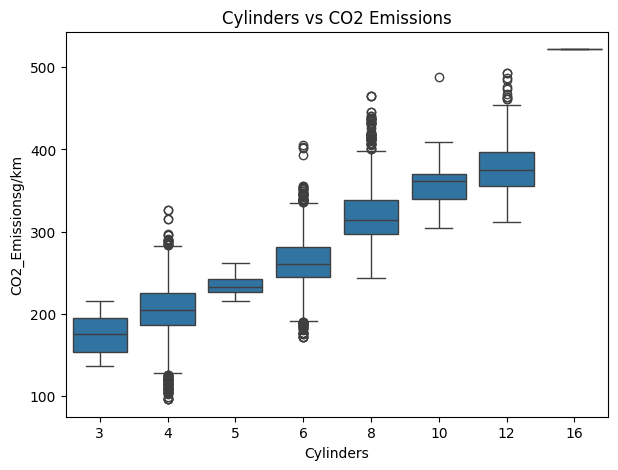

Similarly, cylinder count shows a clear pattern, where vehicles with more cylinders exhibit higher emission levels. This highlights the impact of engine power and design on fuel consumption and emissions.


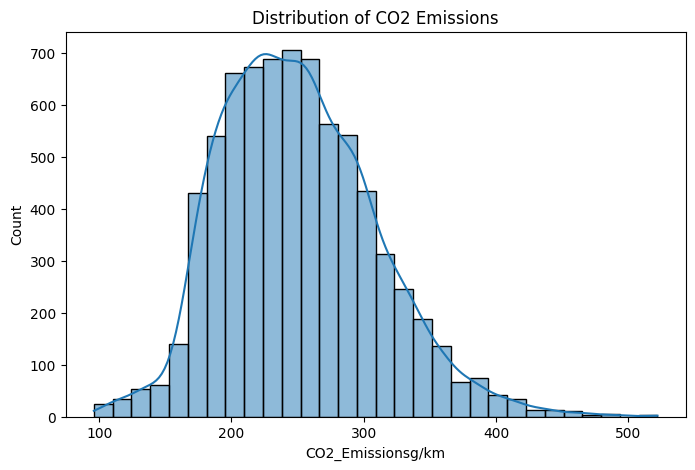

The distribution of CO₂ emissions further shows that most vehicles fall within a moderate emission range, with a small number of high-emission outliers representing larger or high-performance vehicles.Overall, these visualizations confirm that fuel consumption, engine size, and engine configuration are key factors influencing CO₂ emissions, with fuel consumption being the most dominant.


In [17]:
print("Visual Analysis of CO₂ Emissions to better understand how CO₂ emissions vary with different numerical variables, several visualizations were created.")

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Fuel_Consumption_Comb_L/100_km',
    y='CO2_Emissionsg/km',
    data=df
)
plt.title("Fuel Consumption vs CO2 Emissions")
plt.show()

print("The relationship between fuel consumption and CO₂ emissions shows a near-perfect linear trend, indicating that fuel consumption is the strongest predictor of emissions. Vehicles that consume more fuel consistently produce higher emissions, demonstrating a direct proportional relationship.")

plt.figure(figsize=(7,5))
sns.scatterplot(x='Engine_SizeL', y='CO2_Emissionsg/km', data=df)
plt.title("Engine Size vs CO2 Emissions")
plt.show()
print("The analysis of engine size reveals a strong positive relationship with emissions. Vehicles with larger engines tend to emit significantly more CO₂, as larger engines require more fuel for operation.")

plt.figure(figsize=(7,5))
sns.boxplot(x='Cylinders', y='CO2_Emissionsg/km', data=df)
plt.title("Cylinders vs CO2 Emissions")
plt.show()

print("Similarly, cylinder count shows a clear pattern, where vehicles with more cylinders exhibit higher emission levels. This highlights the impact of engine power and design on fuel consumption and emissions.")

plt.figure(figsize=(8,5))
sns.histplot(df['CO2_Emissionsg/km'], bins=30, kde=True)
plt.title("Distribution of CO2 Emissions")
plt.show()

print("The distribution of CO₂ emissions further shows that most vehicles fall within a moderate emission range, with a small number of high-emission outliers representing larger or high-performance vehicles.Overall, these visualizations confirm that fuel consumption, engine size, and engine configuration are key factors influencing CO₂ emissions, with fuel consumption being the most dominant.")

Q5) Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.


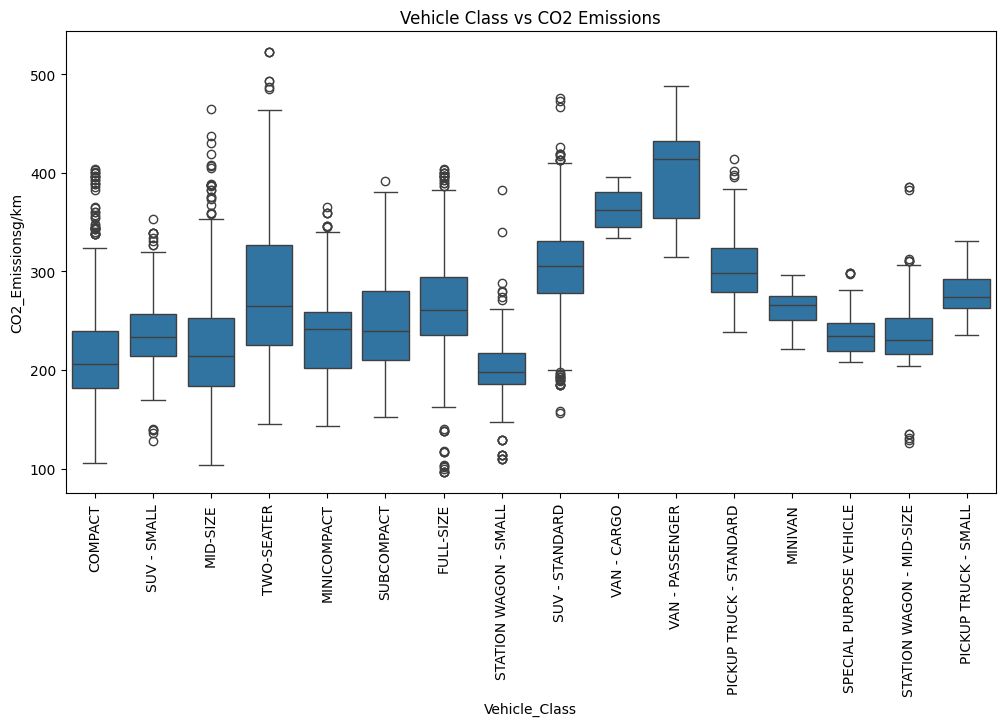

Interpretation
Larger vehicle categories such as Vans, SUVs, and Pickup Trucks show significantly higher median CO₂ emissions,
often exceeding 300 g/km. Smaller vehicle classes such as Compact, Subcompact, and Minicompact exhibit lower emissions,
typically in the 180–250 g/km range. Utility vehicles designed for cargo or passenger capacity tend to have greater variability,
reflecting differences in engine configurations. The spread within each class indicates that engine size and fuel type still influence emissions within the same category.


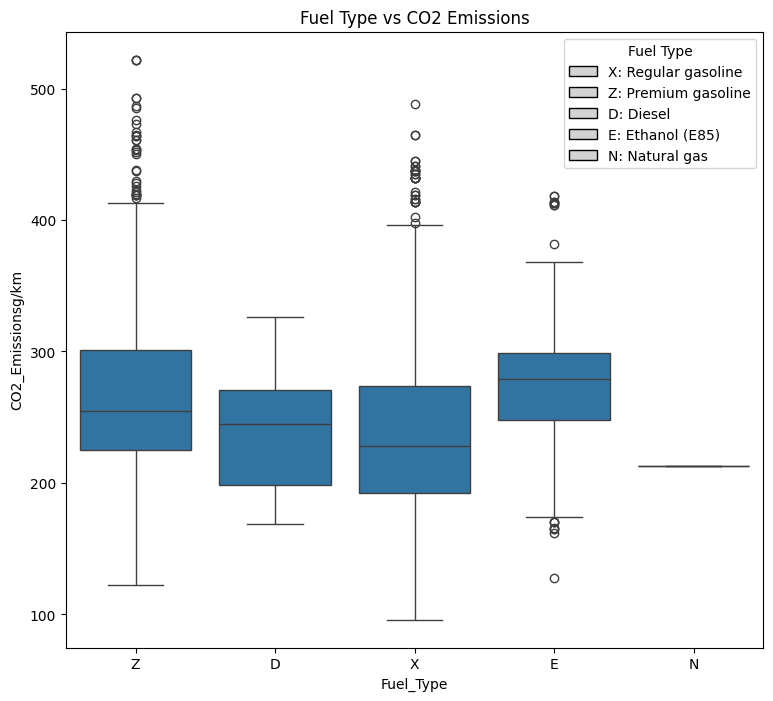

Interpretation
Vehicles using diesel (D) tend to show relatively lower median emissions compared to gasoline-powered vehicles. Regular (X) and
Premium gasoline (Z) vehicles exhibit moderate to high emissions, with a wider spread due to variation in vehicle types. Ethanol (E85)
vehicles appear to have higher emission ranges, which may be influenced by lower fuel efficiency. Natural gas (N) vehicles show lower and
tightly clustered emissions, though the smaller sample size limits strong conclusions.


In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Vehicle_Class', y='CO2_Emissionsg/km', data=df)
plt.xticks(rotation=90)
plt.title("Vehicle Class vs CO2 Emissions")
plt.show()

print("Interpretation")

print("Larger vehicle categories such as Vans, SUVs, and Pickup Trucks show significantly higher median CO₂ emissions,\noften exceeding 300 g/km. Smaller vehicle classes such as Compact, Subcompact, and Minicompact exhibit lower emissions,\ntypically in the 180–250 g/km range. Utility vehicles designed for cargo or passenger capacity tend to have greater variability,\nreflecting differences in engine configurations. The spread within each class indicates that engine size and fuel type still influence emissions within the same category.")

import matplotlib.patches as mpatches

plt.figure(figsize=(9,8)) # Increased width from 7 to 9
sns.boxplot(x='Fuel_Type', y='CO2_Emissionsg/km', data=df)
plt.title("Fuel Type vs CO2 Emissions")

# Create custom legend handles and labels
legend_elements = [
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='X: Regular gasoline'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='Z: Premium gasoline'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='D: Diesel'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='E: Ethanol (E85)'),
    mpatches.Patch(facecolor='lightgray', edgecolor='black', label='N: Natural gas')
]

# Add the legend to the plot
plt.legend(handles=legend_elements, loc='upper right', title='Fuel Type')

plt.show()

print("Interpretation")

print("Vehicles using diesel (D) tend to show relatively lower median emissions compared to gasoline-powered vehicles. Regular (X) and\nPremium gasoline (Z) vehicles exhibit moderate to high emissions, with a wider spread due to variation in vehicle types. Ethanol (E85)\nvehicles appear to have higher emission ranges, which may be influenced by lower fuel efficiency. Natural gas (N) vehicles show lower and\ntightly clustered emissions, though the smaller sample size limits strong conclusions.")

Q6) Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

**Analysis of Unusual Emission Patterns**

The dataset was analyzed to identify vehicles with unusually high and low CO₂ emissions compared to others.

Vehicles with exceptionally high emissions (above 450 g/km) include models from manufacturers such as Ford, Lamborghini, Chevrolet, and GMC. These vehicles are characterized by large engine sizes (typically above 6.0L), high cylinder counts (8–12 cylinders), and very high fuel consumption levels (around 19–21 L/100 km). These attributes indicate that such vehicles are likely high-performance or heavy-duty models designed for power rather than efficiency.

In contrast, vehicles with low emissions (below 130 g/km), such as those from Honda, Toyota, and Lexus, exhibit significantly smaller engine sizes (1.5L–2.0L), fewer cylinders (typically 4), and much lower fuel consumption (approximately 4.7–5.6 L/100 km). These vehicles are designed for fuel efficiency and lower environmental impact.

The comparison highlights a substantial difference in emission levels between high-performance and fuel-efficient vehicles. While most outliers follow expected patterns based on engine size and fuel consumption, these observations reinforce that fuel consumption is the primary driver of CO₂ emissions, with engine size and cylinder count acting as supporting factors.

No major anomalies contradicting the general trend were observed, indicating that the dataset is consistent and aligns well with real-world expectations.



In [19]:
high_emit = df[df['CO2_Emissionsg/km'] > 450]
high_emit[['Make','Engine_SizeL','Cylinders','Fuel_Type','Fuel_Consumption_Comb_L/100_km','CO2_Emissionsg/km']].head()

,Make,Engine_SizeL,Cylinders,Fuel_Type,Fuel_Consumption_Comb_L/100_km,CO2_Emissionsg/km
349,FORD,6.8,10,X,21.2,488
1743,LAMBORGHINI,6.5,12,Z,19.7,453
2434,CHEVROLET,6.0,8,X,19.8,465
2663,GMC,6.0,8,X,19.8,465
2873,LAMBORGHINI,6.5,12,Z,19.3,452


In [20]:
# Low emission vehicles
low_emit = df[df['CO2_Emissionsg/km'] < 130]
low_emit[['Make','Engine_SizeL','Cylinders','Fuel_Type','Fuel_Consumption_Comb_L/100_km','CO2_Emissionsg/km']].head()

,Make,Engine_SizeL,Cylinders,Fuel_Type,Fuel_Consumption_Comb_L/100_km,CO2_Emissionsg/km
415,FORD,2.0,4,X,5.5,126
487,HONDA,2.0,4,X,4.8,110
659,LEXUS,1.8,4,X,5.6,129
992,TOYOTA,1.8,4,X,4.8,110
993,TOYOTA,1.5,4,X,4.7,108


Q7) Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.


To prepare the dataset for model building, several preprocessing steps were performed to ensure that features are appropriately structured and suitable for machine learning algorithms.

First, the ‘Model’ column was removed as it represents highly specific identifiers that do not contribute to generalizable patterns in emissions.

Next, multicollinearity among fuel consumption variables was addressed. Since city, highway, and combined fuel consumption metrics are highly correlated, only the combined fuel consumption feature was retained, while the others were removed to reduce redundancy and improve model stability.

Categorical variables, including make, vehicle class, transmission, and fuel type, were converted into numerical representations using one-hot encoding. This transformation allows machine learning models to interpret categorical information effectively.

Finally, the dataset was split into input features (X) and target variable (y), where CO₂ emissions represent the target. The data was further divided into training and testing sets to enable proper model evaluation and prevent overfitting.

These preprocessing steps ensure that the dataset is clean, structured, and optimized for building accurate and interpretable predictive models.

In [21]:
df_model = df.copy()
df_model.head()

,Make,Vehicle_Class,Engine_SizeL,Cylinders,Transmission,Fuel_Type,Fuel_Consumption_City_L/100_km,Fuel_Consumption_Hwy_L/100_km,Fuel_Consumption_Comb_L/100_km,Fuel_Consumption_Comb_mpg,CO2_Emissionsg/km
0,ACURA,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


**Multi-Collinearity Check**

Fromour confusion matrix, it is evident that fuel consumption variables (city, highway, and mpg) are highly correlated  and were removed to address multicollinearity. The combined fuel consumption metric was retained as it provides a comprehensive measure of fuel usage.

In [22]:
df_model = df.copy()
df_model = df_model.drop([
    'Fuel_Consumption_City_L/100_km',
    'Fuel_Consumption_Hwy_L/100_km',
    'Fuel_Consumption_Comb_mpg'
], axis=1)

In [23]:
df_model.head()

,Make,Vehicle_Class,Engine_SizeL,Cylinders,Transmission,Fuel_Type,Fuel_Consumption_Comb_L/100_km,CO2_Emissionsg/km
0,ACURA,COMPACT,2.0,4,AS5,Z,8.5,196
1,ACURA,COMPACT,2.4,4,M6,Z,9.6,221
2,ACURA,COMPACT,1.5,4,AV7,Z,5.9,136
3,ACURA,SUV - SMALL,3.5,6,AS6,Z,11.1,255
4,ACURA,SUV - SMALL,3.5,6,AS6,Z,10.6,244


**Encode Categorical Variables**

In [24]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,Engine_SizeL,Cylinders,Fuel_Consumption_Comb_L/100_km,CO2_Emissionsg/km,Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,Make_BMW,Make_BUGATTI,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel_Type_E,Fuel_Type_N,Fuel_Type_X,Fuel_Type_Z
0,2.0,4,8.5,196,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2.4,4,9.6,221,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1.5,4,5.9,136,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,3.5,6,11.1,255,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3.5,6,10.6,244,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [25]:
X = df_model.drop('CO2_Emissionsg/km', axis=1)
y = df_model['CO2_Emissionsg/km']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8)Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

To estimate CO₂ emissions, a Linear Regression model was developed using the prepared dataset. Linear regression was chosen due to its simplicity and interpretability, allowing clear understanding of how each feature influences emissions.

The model was trained using the selected numerical and encoded categorical features, with CO₂ emissions as the target variable. Predictions were generated on the test dataset to evaluate performance.

The model captures relationships between features and emissions by assigning coefficients to each variable, indicating their contribution to the predicted output. Features such as fuel consumption, engine size, and cylinder count received positive coefficients, indicating that increases in these variables lead to higher CO₂ emissions.

Among all features, fuel consumption (combined) emerged as the most influential factor, with the highest impact on predicted emissions. This aligns with earlier analysis, confirming that fuel usage is the primary driver of CO₂ output.

Categorical variables, after encoding, also contribute to the model by capturing differences across vehicle types, transmission systems, and fuel categories.

Overall, the linear regression model effectively captures the underlying relationships in the dataset and provides a transparent way to understand how different vehicle characteristics influence CO₂ emissions.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
7261,253,254.833840
4489,344,339.418255
1539,322,326.695051
3532,297,295.525499
6418,308,305.689896


In [30]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
2,Fuel_Consumption_Comb_L/100_km,22.156357
8,Make_BUGATTI,12.020582
12,Make_CHRYSLER,8.594898
13,Make_DODGE,6.225034
16,Make_GENESIS,6.000842
28,Make_MASERATI,5.343719
15,Make_FORD,5.247339
69,Transmission_AM9,5.203755
35,Make_RAM,4.887573
27,Make_LINCOLN,4.730226


**Model Interpretation and Feature Influence**

The coefficients of the linear regression model provide insight into how different features influence CO₂ emissions.

The most significant predictor is fuel consumption (combined), which has the highest coefficient (~22.06). This indicates that for every unit increase in fuel consumption (L/100 km), CO₂ emissions increase substantially, confirming that fuel usage is the primary driver of emissions.

Categorical features, particularly vehicle manufacturers, also contribute to emission levels. Brands such as Bugatti, Chrysler, Dodge, and Ford show higher positive coefficients, suggesting that vehicles from these manufacturers tend to have higher emissions relative to the baseline category. This may be due to differences in vehicle design, performance orientation, or engine configurations.

Additionally, certain transmission types, such as AM9, exhibit positive coefficients, indicating a moderate impact on emissions, possibly due to variations in efficiency and driving dynamics.

Overall, the model demonstrates that while fuel consumption is the dominant factor influencing CO₂ emissions, other variables such as vehicle brand and transmission characteristics introduce additional variation, reflecting differences in engineering design and performance across vehicles.

9)Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

The performance of the linear regression model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The model achieved a MAE of approximately 3.36 g/km, indicating that the average prediction error is very low. Given the range of CO₂ emissions in the dataset, this reflects a high level of prediction accuracy.

The RMSE of approximately 6.47 g/km is only slightly higher than the MAE, suggesting that the model does not suffer from large prediction errors and maintains consistent performance across observations.

The R² score of 0.988 indicates that the model explains nearly 98.8% of the variance in CO₂ emissions, demonstrating excellent explanatory power.

Overall, the model performs exceptionally well, accurately capturing the relationship between vehicle features and emissions. This strong performance is largely driven by the inclusion of fuel consumption variables, which have a direct and linear relationship with CO₂ emissions.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.0951960683278994
RMSE: 5.906104319905712
R2 Score: 0.9898587654900585


10)Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

The analysis identifies several key factors influencing CO₂ emissions, with fuel consumption emerging as the most significant driver. Vehicles that consume more fuel consistently produce higher emissions, indicating a direct relationship between fuel usage and CO₂ output.

Engine-related characteristics such as engine size and number of cylinders also play a crucial role, as larger and more powerful engines require more fuel. Additionally, vehicle class impacts emissions, with larger vehicles such as SUVs and trucks exhibiting higher emission levels compared to smaller, compact vehicles. Fuel type introduces further variation, although its impact is less significant compared to fuel consumption and engine characteristics.

Based on these findings, several recommendations can be made:

For automotive manufacturers: Focus on improving fuel efficiency through optimized engine design, lightweight materials, and adoption of hybrid and electric technologies. Enhancing transmission efficiency can also contribute to reduced fuel consumption.
For policymakers: Implement stricter fuel efficiency standards and provide incentives for low-emission vehicles. Policies promoting alternative fuels and discouraging high-emission vehicles can significantly reduce overall emissions.
For consumers: Opt for fuel-efficient vehicles with smaller engines and consider environmentally friendly alternatives such as hybrid or electric vehicles.

Overall, the study highlights that reducing fuel consumption is the most effective strategy for lowering CO₂ emissions, and coordinated efforts across manufacturers, policymakers, and consumers are essential to achieve sustainable outcomes.

In [34]:
# 1. Install the necessary conversion tools
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

# 2. Convert the notebook to PDF
# Replace 'Your_Notebook_Name.ipynb' with your actual file name
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Scaler AIML/casestudies/Co2_emissions_casestudy/Co2_Emissions_Casestudy.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
[NbConvertApp] Converting notebook /content/drive/MyDrive/Scaler AIML/casestudies/Co2_emissions_casestudy/Co2_Emissions_Casestudy.ipynb to pdf
[NbConvertApp] Support files will be in Co2_Emissions_Casestudy_files/
[NbConvertApp] Making directory ./Co2_Emissions_Casestudy_files
[NbConvertApp] Writing 95784 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbCo